In [45]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append(f"./../")
from src.graphs import StaticGraph, DynamicGraph
from qiskit.quantum_info import Statevector, Operator, state_fidelity
from scipy.linalg import expm
import matplotlib.pyplot as plt
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


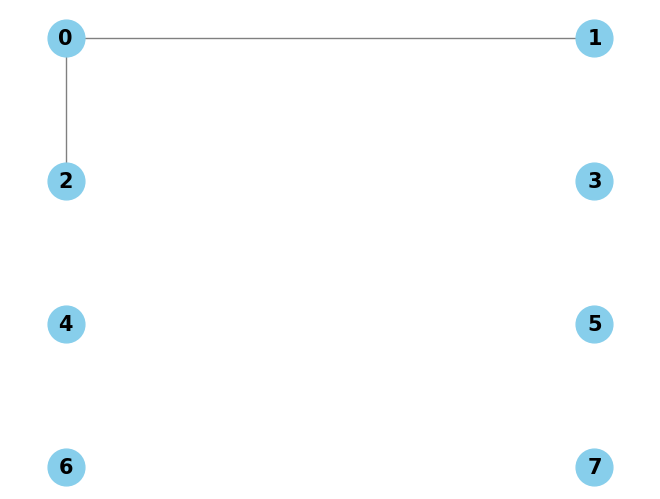

In [46]:
edges = {('000','010'),
         ('000','001')}

G = StaticGraph(edges)
G.draw()

In [47]:
t = 0.3
graph_sequence = [(G, t)]
dyn_G = DynamicGraph(graph_sequence)

In [48]:
psi_0 = Statevector.from_label('0'*G.n_qubits)
print('Initial State: ')
psi_0.draw('latex')

Initial State: 


<IPython.core.display.Latex object>

In [49]:
time_evo_op = dyn_G.time_evo_op()
print('Exact Time Evolution Operator: ')
time_evo_op.draw('latex')

Exact Time Evolution Operator: 


<IPython.core.display.Latex object>

In [50]:
psi_target = psi_0.evolve(time_evo_op)
print('Target (Exact) State: ')
psi_target.draw('latex')

Target (Exact) State: 


<IPython.core.display.Latex object>

In [51]:
edges1 = {('000','010')}
edges2 = {('000','001')}

G1 = StaticGraph(edges1)
G2 = StaticGraph(edges2)

T = 1000
delta_t = 0.1
t_steps = int(T/delta_t)

graph_sequence = [(G1, delta_t), (G2, delta_t)] * t_steps
dyn_G = DynamicGraph(graph_sequence)

In [52]:
time_evo_op = dyn_G.time_evo_op()
print('Approximated Time Evolution Operator: ')
time_evo_op.draw('latex')

Approximated Time Evolution Operator: 


<IPython.core.display.Latex object>

In [53]:
psi_out = psi_0.evolve(time_evo_op)
print('Output (Approximated) State: ')
psi_out.draw('latex')

Output (Approximated) State: 


<IPython.core.display.Latex object>

In [54]:
fid = state_fidelity(psi_out, psi_target)
infid = 1 - fid

print(f'State Infidelity (Difference between Exact State and Approximated State): {round(infid, 3)}')

State Infidelity (Difference between Exact State and Approximated State): 0.049
